# Career-Fit Prediction — Hand-made ML Model (research notebook)

**Goal.** Map a learner's measured Java competency profile to a **best-fit software role**
with a **calibrated** confidence, using a *from-scratch* multinomial logistic regression
(softmax + gradient descent in NumPy — no scikit-learn/torch for the model itself).

**Why weak supervision.** There is no public dataset of *(student-quiz-profile → real job)*.
So we encode domain knowledge — an O*NET/ESCO-informed **role→competency matrix** — and
generate synthetic learners labelled by competency *shape* (cosine to the matrix). The
Stack Overflow Developer Survey supplies realistic **class priors** and a **face-validity**
cross-check. This is stated as a limitation, not hidden.

**Instrumentation note.** The *model* is hand-written; `matplotlib`/`seaborn`/`sklearn.metrics`
are used **only** for plots and scoring curves (ROC/PR/confusion), which is standard.

**Outputs.** `career_artifacts.zip` = `model_weights.npz`, `scaler.json`, `role_matrix.json`,
`label_map.json`, `feature_axes.json`, `metrics.json` — dropped into
`app/services/career/artifacts/` to serve the model.

## 1. Setup — install dependencies (▶ RUN THIS CELL FIRST)

This installs everything the notebook needs **into the current kernel**, on Colab or locally
(VS Code / Jupyter). It's safe to re-run — already-installed packages are skipped. If you're
running locally and the *imports* cell below fails right after this, **restart the kernel once**
(VS Code: the ↻ button) so it picks up the freshly installed packages, then Run All again.

In [1]:
# --- required environment (run before anything else) ---
%pip install -q numpy pandas matplotlib seaborn scikit-learn
print("✅ Dependencies installed. If the next cell errors with ModuleNotFound, RESTART the kernel once.")

Note: you may need to restart the kernel to use updated packages.
✅ Dependencies installed. If the next cell errors with ModuleNotFound, RESTART the kernel once.


In [2]:
import sys, os
IN_COLAB = "google.colab" in sys.modules
import numpy as np, pandas as pd, json, io, zipfile, urllib.request
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
try:
    get_ipython().run_line_magic("matplotlib", "inline")  # embed figures in the notebook
except Exception:
    pass
sns.set_theme(context="notebook", style="whitegrid")
np.random.seed(42)
print("✅ Imports OK. Running on Colab:", IN_COLAB)

✅ Imports OK. Running on Colab: False


## 2. The hand-made model core (read this — the gradient descent lives here)

The next cell writes `career_lib.py` (embedded verbatim) and imports it. The learning
algorithm is `train_softmax` — full-batch gradient descent on the cross-entropy loss:

$$P(y=k\mid x)=\mathrm{softmax}(Wx+b)_k,\qquad
\mathcal{L}=-\tfrac1N\sum_i\log P(y_i\mid x_i)+\lambda\lVert W\rVert^2$$

with the update $W \leftarrow W - \eta\,\nabla_W\mathcal{L}$. Calibration (`fit_temperature`)
divides the logits by a learned scalar $T$ so the confidences match observed accuracy.

In [26]:
%%writefile career_lib.py
"""career_lib — hand-made career-fit model core (NumPy only).

Single source of truth shared by the Colab notebook, ``train.py`` and ``evaluate.py``.
Deliberately depends on **numpy only** so it runs unchanged on Google Colab and inside
the ``knowledge-analysis`` service container (which already ships numpy).

What lives here:
  * the 8 competency axes and the role taxonomy (§3 of the plan);
  * a default O*NET/ESCO-informed role -> competency-importance matrix (the "knowledge");
  * a weak-supervision synthetic-learner generator (labels by competency *shape*);
  * a from-scratch multinomial-logistic-regression trainer (softmax + cross-entropy +
    batch gradient descent + L2) — written out by hand, no sklearn/torch;
  * temperature-scaling calibration and Expected-Calibration-Error;
  * standardisation + inference helpers used by both training and serving.

Nothing here imports matplotlib/sklearn — those are *instrumentation* used only in the
notebook/eval for plots and scoring curves, never by the model itself.
"""
from __future__ import annotations

from typing import Dict, List, Tuple

import numpy as np

# --------------------------------------------------------------------------- axes
# Order is the contract: the trained weight columns, the scaler, and the service
# featuriser must all use THIS order. It is exported to feature_axes.json.
FEATURE_AXES: List[str] = ["A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8"]
AXIS_NAMES: Dict[str, str] = {
    "A1": "Programming Fundamentals",
    "A2": "OOP & Design",
    "A3": "Data Structures",
    "A4": "Algorithms & Complexity",
    "A5": "Robustness / Error Handling",
    "A6": "Concurrency",
    "A7": "Problem-solving Fluency",
    "A8": "Independent Authorship",
}

# Roles the classifier is allowed to output. These are SE-scoped: every one of them
# is *justifiable from Java signal*. Cross-domain roles (Data/ML, Frontend, Mobile,
# DevOps) are intentionally NOT classes here — the service surfaces them only as
# low-confidence "aspirational" matches, because a Java quiz cannot evidence them.
ROLES: List[str] = [
    "Junior Java / Backend Developer",
    "General Software Engineer",
    "DSA / Algorithms-focused Engineer",
    "Systems / Concurrency Engineer",
    "QA / Test Automation Engineer",
]

# Role -> per-axis *importance/requirement* in [0, 1]. O*NET/ESCO-informed expert
# weights (e.g. O*NET 15-1252 Software Developers rates Programming / Complex Problem
# Solving highly). Treated as both the requirement profile (for gap analysis) and the
# competency *shape* used to label synthetic learners. build_matrix.py writes this to
# role_matrix.json; it can be cross-checked against fazni/roles-based-on-skills.
DEFAULT_ROLE_MATRIX: Dict[str, List[float]] = {
    # A1    A2    A3    A4    A5    A6    A7    A8
    "Junior Java / Backend Developer":   [0.70, 0.80, 0.72, 0.58, 0.72, 0.50, 0.62, 0.62],
    "General Software Engineer":         [0.72, 0.72, 0.62, 0.60, 0.62, 0.45, 0.72, 0.62],
    "DSA / Algorithms-focused Engineer": [0.80, 0.50, 0.90, 0.95, 0.50, 0.40, 0.88, 0.70],
    "Systems / Concurrency Engineer":    [0.80, 0.62, 0.72, 0.72, 0.70, 0.95, 0.72, 0.70],
    "QA / Test Automation Engineer":     [0.62, 0.62, 0.52, 0.42, 0.88, 0.32, 0.62, 0.60],
}

# Map a free-text Stack Overflow DevType onto our role taxonomy (for priors + the
# face-validity cross-check in the notebook). Substring match, first hit wins.
DEVTYPE_TO_ROLE: Dict[str, str] = {
    "back-end": "Junior Java / Backend Developer",
    "embedded": "Systems / Concurrency Engineer",
    "system": "Systems / Concurrency Engineer",
    "devops": "Systems / Concurrency Engineer",
    "qa": "QA / Test Automation Engineer",
    "test": "QA / Test Automation Engineer",
    "academic": "DSA / Algorithms-focused Engineer",
    "scientist": "DSA / Algorithms-focused Engineer",
    "engineer, data": "DSA / Algorithms-focused Engineer",
    "full-stack": "General Software Engineer",
    "developer, ": "General Software Engineer",
}


# ----------------------------------------------------------------- matrix helpers
def matrix_to_array(role_matrix: Dict[str, List[float]], roles: List[str]) -> np.ndarray:
    """Return the (K, 8) requirement matrix in canonical role/axis order."""
    return np.array([role_matrix[r] for r in roles], dtype=float)


def role_index(roles: List[str]) -> Dict[str, int]:
    return {r: i for i, r in enumerate(roles)}


# --------------------------------------------------------- synthetic training data
def _cosine_rows(X: np.ndarray, M: np.ndarray) -> np.ndarray:
    """Row-wise cosine similarity between every learner (X) and every role (M)."""
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)
    Mn = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)
    return Xn @ Mn.T  # (N, K)


def sample_synthetic_learners(
    M: np.ndarray,
    n_samples: int = 12000,
    priors: np.ndarray | None = None,
    label_noise: float = 0.08,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray]:
    """Generate (X, y) synthetic learners by weak supervision.

    We have no real (student-profile -> job) labels, so we *encode domain knowledge*:
    a learner is labelled with the role whose competency **shape** they best match
    (cosine similarity to the requirement matrix). Magnitude (overall level) is varied
    independently so the classifier learns *specialisation shape*, not just "strong vs
    weak" — overall level is reported separately as readiness.

    Coverage is guaranteed by drawing half the pool around scaled role prototypes
    (varying level, preserving shape) and half from a broad Beta spread (boundary
    cases). ``label_noise`` flips a fraction of labels to the runner-up role so the
    problem is not linearly trivial — this keeps the loss curves, confusion matrix and
    calibration diagram realistic.
    """
    rng = np.random.default_rng(seed)
    K, d = M.shape
    half = n_samples // 2

    # (a) prototype-anchored: random role, random overall level, shape preserved + jitter
    proto_roles = rng.integers(0, K, size=half)
    levels = rng.uniform(0.40, 1.10, size=(half, 1))
    X_proto = np.clip(M[proto_roles] * levels + rng.normal(0, 0.10, size=(half, d)), 0, 1)

    # (b) broad coverage: Beta(2,2) per axis spreads across [0,1], centred ~0.5
    X_beta = rng.beta(2.0, 2.0, size=(n_samples - half, d))

    X = np.vstack([X_proto, X_beta])
    rng.shuffle(X)

    # Label every learner by best-matching competency shape.
    sims = _cosine_rows(X, M)
    y = sims.argmax(axis=1)

    # Inject label noise -> flip to the runner-up role for a fraction of rows.
    flip = rng.random(len(y)) < label_noise
    runner_up = sims.argsort(axis=1)[:, -2]
    y[flip] = runner_up[flip]

    # Optionally bias class proportions toward real-world priors (SO DevType).
    # Soften 50/50 toward uniform so a dominant class (e.g. back-end) doesn't starve the
    # minority roles of training data — keeps macro-F1 and calibration healthy while still
    # reflecting real base rates.
    if priors is not None:
        priors = priors / priors.sum()
        uniform = np.ones_like(priors) / len(priors)
        priors = 0.5 * priors + 0.5 * uniform
        idx = _resample_to_priors(y, priors, rng)
        X, y = X[idx], y[idx]

    return X.astype(float), y.astype(int)


def _resample_to_priors(y: np.ndarray, priors: np.ndarray, rng) -> np.ndarray:
    """Resample row indices (with replacement) so class freq ≈ priors, keeping size."""
    n = len(y)
    by_class = [np.where(y == k)[0] for k in range(len(priors))]
    target = (priors * n).astype(int)
    target[-1] += n - target.sum()  # fix rounding
    out = []
    for k, cnt in enumerate(target):
        if len(by_class[k]) == 0:
            continue
        out.append(rng.choice(by_class[k], size=cnt, replace=True))
    idx = np.concatenate(out)
    rng.shuffle(idx)
    return idx


# ------------------------------------------------------------- standardisation
def fit_standardizer(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    mu = X.mean(axis=0)
    sd = X.std(axis=0) + 1e-8
    return mu, sd


def apply_standardizer(X: np.ndarray, mu: np.ndarray, sd: np.ndarray) -> np.ndarray:
    return (X - mu) / sd


# --------------------------------------------------- hand-written softmax + GD
def softmax(Z: np.ndarray) -> np.ndarray:
    """Numerically stable row-wise softmax."""
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)


def one_hot(y: np.ndarray, K: int) -> np.ndarray:
    return np.eye(K)[y]


def cross_entropy(P: np.ndarray, Y: np.ndarray) -> float:
    return float(-np.mean(np.sum(Y * np.log(P + 1e-12), axis=1)))


def accuracy(P: np.ndarray, y: np.ndarray) -> float:
    return float((P.argmax(axis=1) == y).mean())


def train_softmax(
    Xz: np.ndarray,
    y: np.ndarray,
    K: int,
    lr: float = 0.5,
    lam: float = 1e-3,
    epochs: int = 1500,
    Xval: np.ndarray | None = None,
    yval: np.ndarray | None = None,
    class_weight: np.ndarray | None = None,
    seed: int = 42,
) -> Dict[str, object]:
    """Multinomial logistic regression by **full-batch gradient descent**, by hand.

    Returns weights and a per-epoch history (train/val loss & accuracy, gradient norm)
    so the notebook can draw the gradient-descent and train-vs-validation curves.
    """
    rng = np.random.default_rng(seed)
    N, d = Xz.shape
    W = rng.normal(0, 0.01, size=(K, d))
    b = np.zeros(K)
    Y = one_hot(y, K)
    cw = np.ones(K) if class_weight is None else class_weight
    sample_w = cw[y][:, None]  # (N,1) per-row weight

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "grad_norm": []}
    for _ in range(epochs):
        Z = Xz @ W.T + b
        P = softmax(Z)
        # weighted cross-entropy gradient + L2
        G = (P - Y) * sample_w / N
        gW = G.T @ Xz + lam * W
        gb = G.sum(axis=0)
        W -= lr * gW
        b -= lr * gb

        hist["train_loss"].append(cross_entropy(P, Y) + lam * float(np.sum(W * W)))
        hist["train_acc"].append(accuracy(P, y))
        hist["grad_norm"].append(float(np.linalg.norm(gW)))
        if Xval is not None and yval is not None:
            Pv = softmax(Xval @ W.T + b)
            hist["val_loss"].append(cross_entropy(Pv, one_hot(yval, K)))
            hist["val_acc"].append(accuracy(Pv, yval))

    return {"W": W, "b": b, "history": hist}


# ------------------------------------------------------- temperature calibration
def logits(X: np.ndarray, W: np.ndarray, b: np.ndarray) -> np.ndarray:
    return X @ W.T + b


def fit_temperature(val_logits: np.ndarray, yval: np.ndarray, iters: int = 300, lr: float = 0.01) -> float:
    """Fit a single scalar temperature T>0 minimising validation NLL (Platt-style).

    Optimised in log-space so T stays positive. T>1 softens over-confident probs.
    """
    logT = 0.0
    Y = one_hot(yval, val_logits.shape[1])
    for _ in range(iters):
        T = np.exp(logT)
        P = softmax(val_logits / T)
        # dNLL/dT via chain rule; collapse to a scalar gradient on logT
        # grad of NLL wrt logits scaled by -logits/T^2; aggregate then * dT/dlogT (=T)
        grad_logits = (P - Y) / len(yval)
        gT = np.sum(grad_logits * (-val_logits / T))
        logT -= lr * gT * T
    return float(np.exp(logT))


def expected_calibration_error(probs: np.ndarray, y: np.ndarray, n_bins: int = 10) -> float:
    """ECE: gap between confidence and accuracy, averaged over confidence bins."""
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == y).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(ece)


# --------------------------------------------------------------------- inference
def predict_proba(
    X_raw: np.ndarray, W: np.ndarray, b: np.ndarray, mu: np.ndarray, sd: np.ndarray, T: float = 1.0
) -> np.ndarray:
    """Full inference path used identically by the service: standardise -> calibrated softmax."""
    Xz = apply_standardizer(np.atleast_2d(X_raw), mu, sd)
    return softmax(logits(Xz, W, b) / T)


def readiness_level(overall_0_100: float, difficulty_reached: str = "medium") -> str:
    """Coarse readiness from overall mastery + the hardest quiz rung answered."""
    ceiling = {"easy": 0, "medium": 1, "hard": 2}.get(difficulty_reached, 1)
    if overall_0_100 >= 75 and ceiling >= 2:
        return "Strong Junior"
    if overall_0_100 >= 55 and ceiling >= 1:
        return "Job-ready (Junior)"
    return "Foundational"


# ------------------------------------------------------ metrics (numpy-only)
def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, K: int) -> np.ndarray:
    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def precision_recall_f1(cm: np.ndarray) -> Dict[str, np.ndarray | float]:
    """Per-class precision/recall/F1 plus macro-F1 from a confusion matrix."""
    tp = np.diag(cm).astype(float)
    prec = tp / (cm.sum(axis=0) + 1e-12)
    rec = tp / (cm.sum(axis=1) + 1e-12)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    return {"precision": prec, "recall": rec, "f1": f1, "macro_f1": float(f1.mean())}


def topk_accuracy(probs: np.ndarray, y: np.ndarray, k: int = 3) -> float:
    topk = np.argsort(-probs, axis=1)[:, :k]
    return float(np.mean([yi in row for yi, row in zip(y, topk)]))


def stratified_split(y: np.ndarray, fracs=(0.7, 0.15, 0.15), seed: int = 42):
    """Return index arrays (train, val, test) keeping class proportions."""
    rng = np.random.default_rng(seed)
    tr, va, te = [], [], []
    for k in np.unique(y):
        idx = np.where(y == k)[0]
        rng.shuffle(idx)
        n = len(idx)
        n_tr = int(fracs[0] * n)
        n_va = int(fracs[1] * n)
        tr.append(idx[:n_tr]); va.append(idx[n_tr:n_tr + n_va]); te.append(idx[n_tr + n_va:])
    out = [np.concatenate(s) for s in (tr, va, te)]
    for s in out:
        rng.shuffle(s)
    return out

Overwriting career_lib.py


In [4]:
import career_lib as cl
M = cl.matrix_to_array(cl.DEFAULT_ROLE_MATRIX, cl.ROLES)
K = len(cl.ROLES)
print("Roles (K=%d):" % K); [print("  %d. %s" % (i, r)) for i, r in enumerate(cl.ROLES)]
print("Axes:", cl.FEATURE_AXES)

Roles (K=5):
  0. Junior Java / Backend Developer
  1. General Software Engineer
  2. DSA / Algorithms-focused Engineer
  3. Systems / Concurrency Engineer
  4. QA / Test Automation Engineer
Axes: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8']


## 3. Get the Stack Overflow survey (public — **no Kaggle login**)

Downloaded straight from Stack Overflow's official GitHub mirror — no account or API token,
on Colab or locally. The full file (~150 MB, 84 columns incl. `DevType`) is **cached** under
`~/.cache/mentora_so`, so it only downloads once. To use a CSV you already have, set `SO_CSV`
to its path and the download is skipped. If the download fails for any reason, the notebook
**falls back to uniform priors** and still trains + plots everything.

In [27]:
# Set SO_CSV to a local full survey CSV to use it; otherwise it auto-downloads the public one.
SO_CSV = None
SO_YEAR = "2023"   # 2023 / 2024 / 2025 all expose the same DevType column
SO_URL = ("https://github.com/StackExchange/Survey/raw/refs/heads/main/"
          "packages/archive/%s/results.csv" % SO_YEAR)
CACHE = os.path.expanduser("~/.cache/mentora_so")

if not SO_CSV:
    try:
        os.makedirs(CACHE, exist_ok=True)
        target = os.path.join(CACHE, "results_%s.csv" % SO_YEAR)
        if not os.path.exists(target) or os.path.getsize(target) < 1_000_000:
            print("Downloading Stack Overflow %s survey (~150 MB, one-time)…" % SO_YEAR)
            urllib.request.urlretrieve(SO_URL, target)
        SO_CSV = target
        print("✅ SO_CSV = %s  (%.0f MB)" % (SO_CSV, os.path.getsize(SO_CSV) / 1e6))
    except Exception as e:
        print("Auto-download failed (%s) -> uniform priors (model still fine)." % e)
        SO_CSV = None
else:
    print("Using provided SO_CSV =", SO_CSV)

✅ SO_CSV = /Users/idea8/.cache/mentora_so/results_2023.csv  (159 MB)


In [28]:
# Class priors from SO DevType. Falls back to uniform if the survey is absent OR the
# CSV has no DevType column (e.g. a 'selected-columns' subset) — with a clear message.
priors, so_df = None, None
if SO_CSV and os.path.exists(SO_CSV):
    df = pd.read_csv(SO_CSV, low_memory=False)
    if "DevType" not in df.columns:
        print("WARNING: %s has no 'DevType' column." % SO_CSV)
        print("  columns found:", list(df.columns)[:10])
        print("  -> This is a reduced/'selected-columns' export. For real priors download the")
        print("     FULL survey_results_public.csv. Using UNIFORM priors for now (model is fine).")
    else:
        so_df = df
        counts = np.ones(K)  # Laplace smoothing so no class is zero
        ridx = cl.role_index(cl.ROLES)
        for cell in so_df["DevType"].dropna():
            low = str(cell).lower()
            for key, role in cl.DEVTYPE_TO_ROLE.items():
                if key in low:
                    counts[ridx[role]] += 1; break
        priors = counts
        print("SO priors:", dict(zip(cl.ROLES, counts.astype(int))))
else:
    print("No SO survey CSV at SO_CSV -> uniform priors (model trains fine).")

# Optional HF cross-check (non-fatal).
try:
    from datasets import load_dataset
    ds = load_dataset("fazni/roles-based-on-skills")
    print("Loaded fazni/roles-based-on-skills:", ds)
except Exception as e:
    print("HF cross-check skipped:", e)

SO priors: {'Junior Java / Backend Developer': np.int64(13746), 'General Software Engineer': np.int64(38174), 'DSA / Algorithms-focused Engineer': np.int64(4542), 'Systems / Concurrency Engineer': np.int64(3976), 'QA / Test Automation Engineer': np.int64(587)}
HF cross-check skipped: No module named 'datasets'


## 4. Synthesize the training set (weak supervision)

In [29]:
X, y = cl.sample_synthetic_learners(M, n_samples=12000, priors=priors, seed=42)
print("X:", X.shape, "y:", y.shape)
counts = np.bincount(y, minlength=K)
for i, r in enumerate(cl.ROLES):
    print("  %-36s %5d" % (r, counts[i]))

X: (12000, 8) y: (12000,)
  Junior Java / Backend Developer       2551
  General Software Engineer             4953
  DSA / Algorithms-focused Engineer     1646
  Systems / Concurrency Engineer        1590
  QA / Test Automation Engineer         1260


### 4a. Class distribution

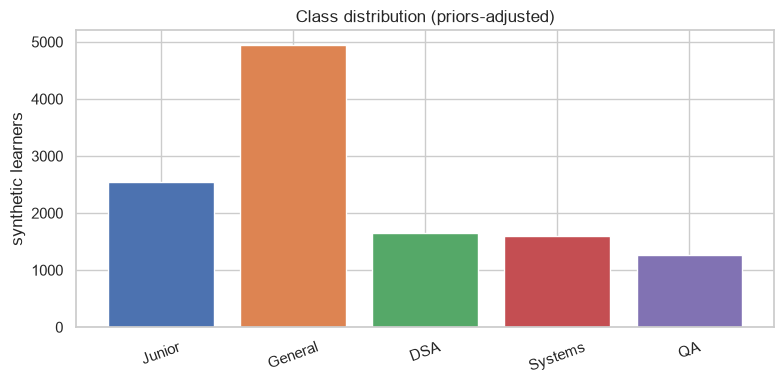

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(K), np.bincount(y, minlength=K), color=sns.color_palette("deep", K))
ax.set_xticks(range(K)); ax.set_xticklabels([r.split(" ")[0] for r in cl.ROLES], rotation=20)
ax.set_ylabel("synthetic learners"); ax.set_title("Class distribution (priors-adjusted)")
plt.tight_layout(); plt.show()
# What this shows: training base rates per role (skewed toward real-world priors if SO loaded).

### 4b. Per-axis competency distributions by role

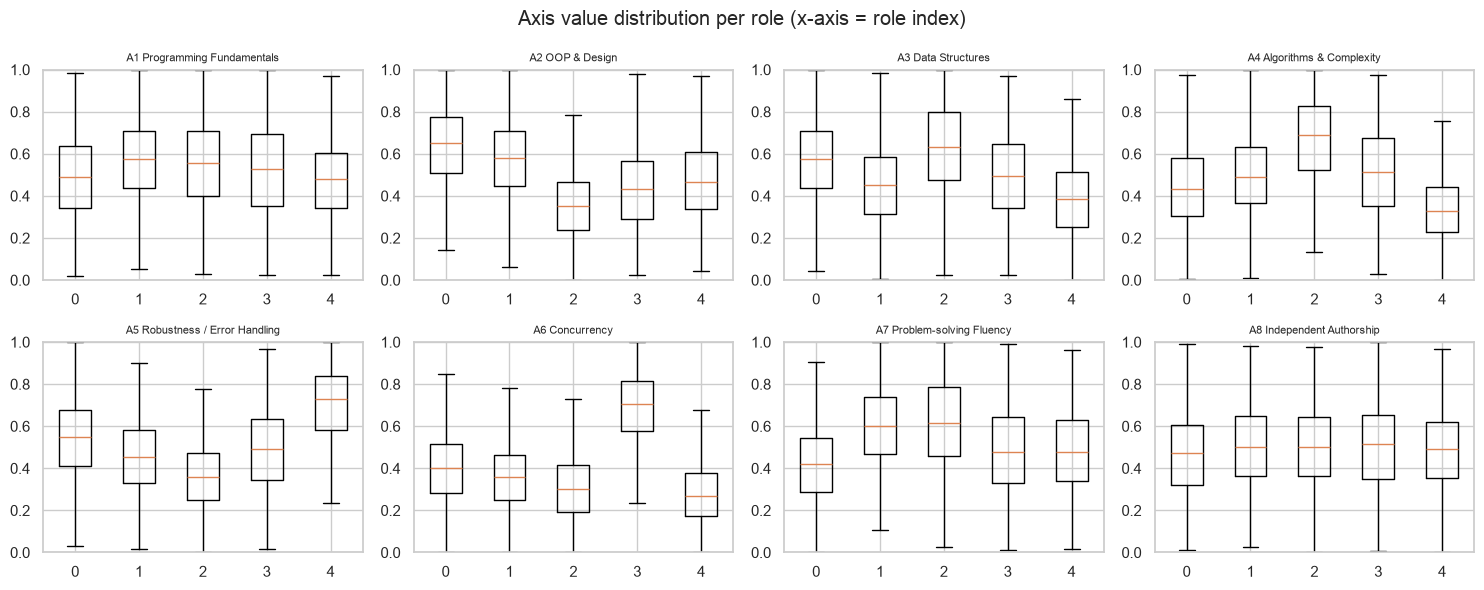

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for a, ax in enumerate(axes.ravel()):
    ax.boxplot([X[y == k, a] for k in range(K)], showfliers=False)
    ax.set_title("%s %s" % (cl.FEATURE_AXES[a], cl.AXIS_NAMES[cl.FEATURE_AXES[a]]), fontsize=8)
    ax.set_xticks(range(1, K + 1)); ax.set_xticklabels(range(K)); ax.set_ylim(0, 1)
plt.suptitle("Axis value distribution per role (x-axis = role index)"); plt.tight_layout(); plt.show()
# What this shows: each role's competency 'shape' — e.g. DSA peaks on A3/A4, Systems on A6.

### 4c. Axis correlation + role→competency matrix

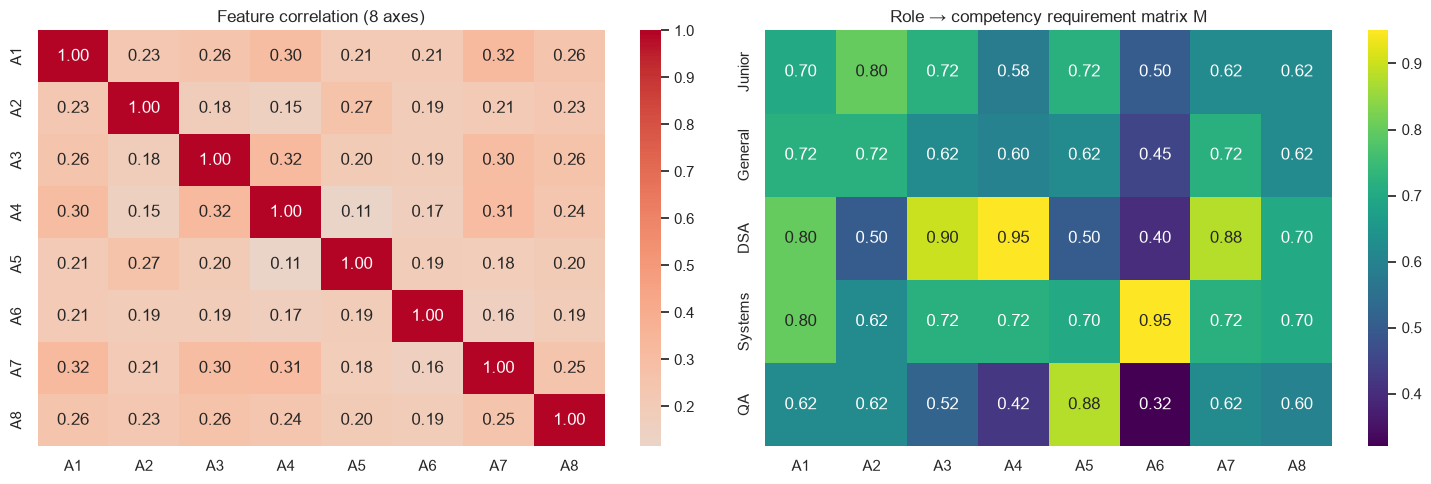

In [31]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(np.corrcoef(X.T), annot=True, fmt=".2f", xticklabels=cl.FEATURE_AXES,
            yticklabels=cl.FEATURE_AXES, cmap="coolwarm", center=0, ax=a1)
a1.set_title("Feature correlation (8 axes)")
sns.heatmap(M, annot=True, fmt=".2f", xticklabels=cl.FEATURE_AXES,
            yticklabels=[r.split(" ")[0] for r in cl.ROLES], cmap="viridis", ax=a2)
a2.set_title("Role → competency requirement matrix M")
plt.tight_layout(); plt.show()

### 4d. PCA — is the feature space separable?

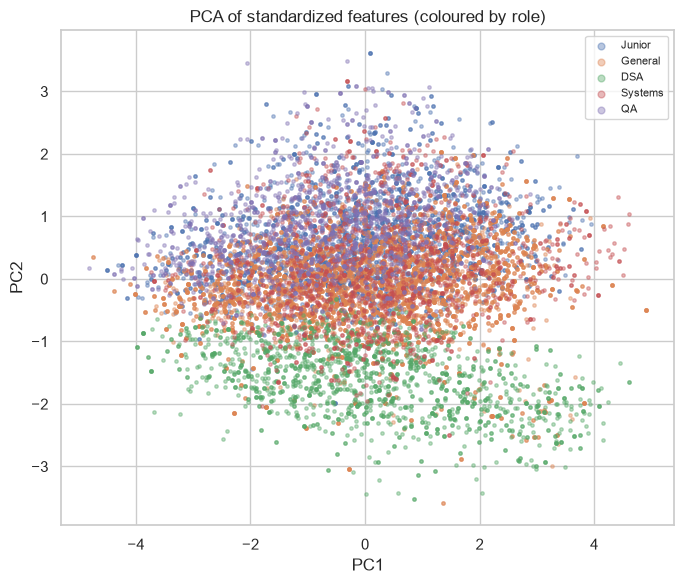

In [11]:
from sklearn.decomposition import PCA
mu_all, sd_all = cl.fit_standardizer(X)
Z2 = PCA(n_components=2, random_state=42).fit_transform(cl.apply_standardizer(X, mu_all, sd_all))
fig, ax = plt.subplots(figsize=(7, 6))
for k in range(K):
    m = y == k
    ax.scatter(Z2[m, 0], Z2[m, 1], s=6, alpha=0.4, label=cl.ROLES[k].split(" ")[0])
ax.legend(markerscale=2, fontsize=8); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("PCA of standardized features (coloured by role)"); plt.tight_layout(); plt.show()
# What this shows: classes overlap (by design — label noise), so the problem isn't trivial.

## 5. Train (hand-written softmax + gradient descent)

In [12]:
tr, va, te = cl.stratified_split(y, seed=42)
mu, sd = cl.fit_standardizer(X[tr])
Xz = cl.apply_standardizer(X, mu, sd)
freq = np.bincount(y[tr], minlength=K).astype(float)
class_weight = freq.sum() / (K * (freq + 1e-9))   # inverse-frequency weighting

res = cl.train_softmax(Xz[tr], y[tr], K, lr=0.5, lam=1e-3, epochs=1500,
                       Xval=Xz[va], yval=y[va], class_weight=class_weight, seed=42)
W, b, hist = res["W"], res["b"], res["history"]
print("final train acc=%.3f  val acc=%.3f" % (hist["train_acc"][-1], hist["val_acc"][-1]))

final train acc=0.861  val acc=0.855


### 5a. Gradient-descent loss curve  +  train-vs-validation

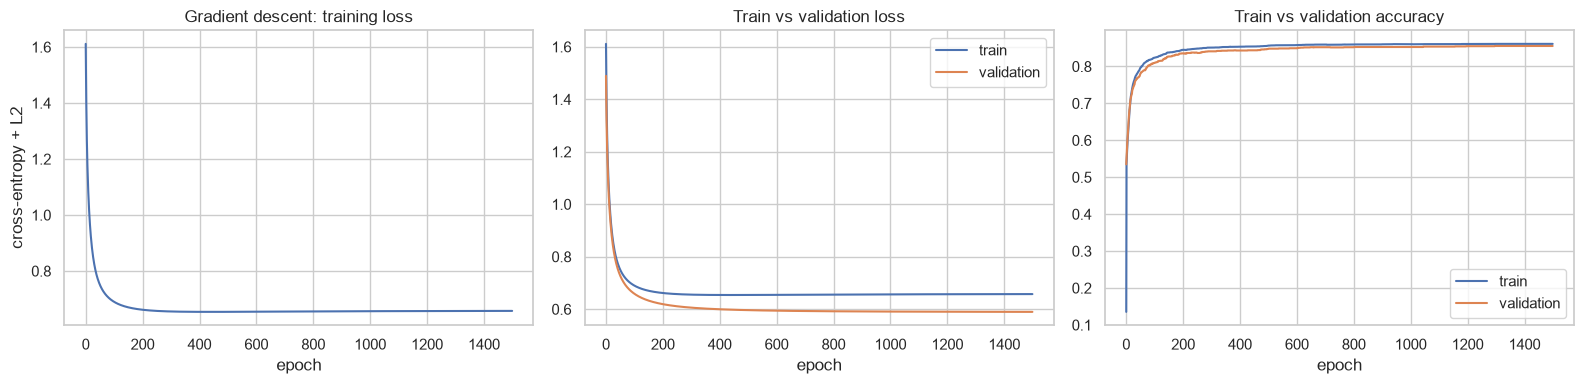

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].plot(hist["train_loss"]); axs[0].set_title("Gradient descent: training loss")
axs[0].set_xlabel("epoch"); axs[0].set_ylabel("cross-entropy + L2")
axs[1].plot(hist["train_loss"], label="train")
axs[1].plot(hist["val_loss"], label="validation"); axs[1].legend()
axs[1].set_title("Train vs validation loss"); axs[1].set_xlabel("epoch")
axs[2].plot(hist["train_acc"], label="train")
axs[2].plot(hist["val_acc"], label="validation"); axs[2].legend()
axs[2].set_title("Train vs validation accuracy"); axs[2].set_xlabel("epoch")
plt.tight_layout(); plt.show()
# What this shows: GD converging; small train/val gap = good generalization (not overfit).

/var/folders/g_/52n_3v110g305z2nm0ctgcb00000gn/T/ipykernel_96928/4160810069.py:4: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/Users/idea8/opt/anaconda3/envs/mentora-kaa/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


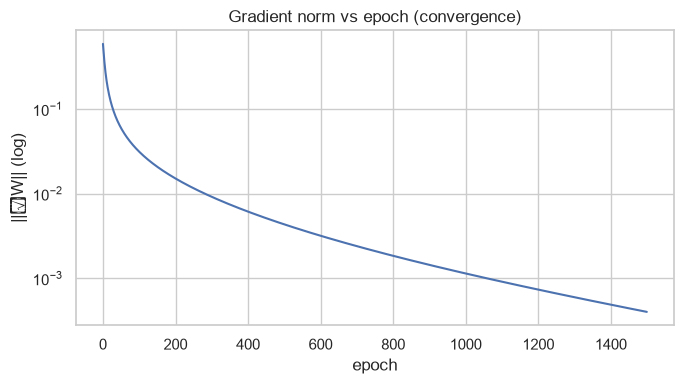

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist["grad_norm"]); ax.set_yscale("log")
ax.set_title("Gradient norm vs epoch (convergence)"); ax.set_xlabel("epoch"); ax.set_ylabel("||∇W|| (log)")
plt.tight_layout(); plt.show()

## 6. Calibration (temperature scaling)

In [15]:
val_logits = cl.logits(Xz[va], W, b)
T = cl.fit_temperature(val_logits, y[va])
test_logits = cl.logits(Xz[te], W, b)
probs_uncal = cl.softmax(test_logits)
probs_cal = cl.softmax(test_logits / T)
ece_b = cl.expected_calibration_error(probs_uncal, y[te])
ece_a = cl.expected_calibration_error(probs_cal, y[te])
print("Temperature T=%.3f   ECE before=%.4f  after=%.4f" % (T, ece_b, ece_a))

Temperature T=1.001   ECE before=0.1522  after=0.1523


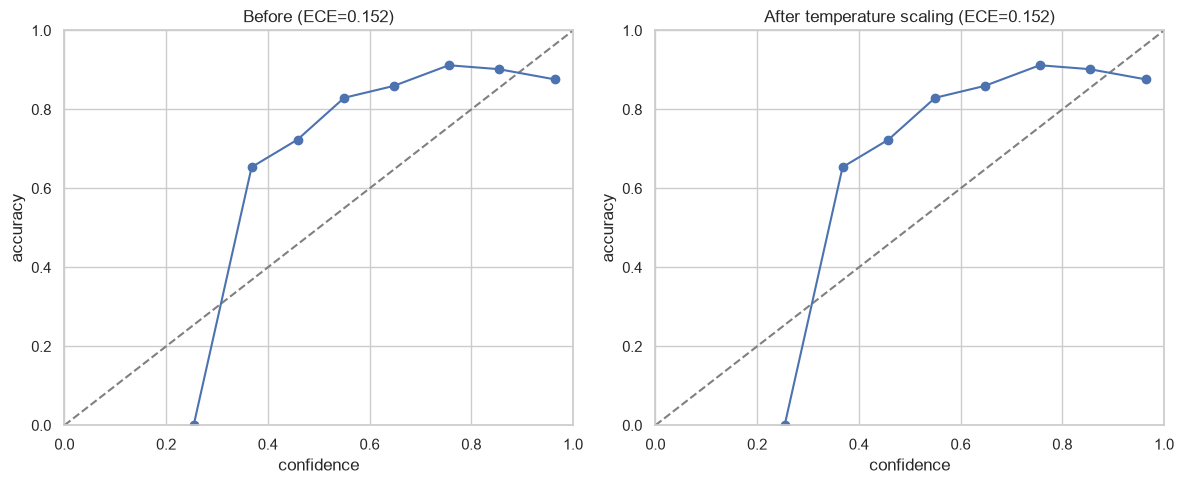

In [16]:
def reliability(ax, probs, yt, title):
    conf, pred = probs.max(1), probs.argmax(1)
    correct = (pred == yt).astype(float)
    bins = np.linspace(0, 1, 11); xs, ys = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any(): xs.append(conf[m].mean()); ys.append(correct[m].mean())
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.plot(xs, ys, "o-"); ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
    ax.set_title(title); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
reliability(a1, probs_uncal, y[te], "Before (ECE=%.3f)" % ece_b)
reliability(a2, probs_cal, y[te], "After temperature scaling (ECE=%.3f)" % ece_a)
plt.tight_layout(); plt.show()
# What this shows: points nearer the diagonal = better-calibrated confidences.

## 7. Evaluation

In [17]:
from sklearn.metrics import classification_report
y_pred = probs_cal.argmax(1)
cm = cl.confusion_matrix(y[te], y_pred, K)
prf = cl.precision_recall_f1(cm)
print("Top-1 acc : %.3f" % (y_pred == y[te]).mean())
print("Top-3 acc : %.3f" % cl.topk_accuracy(probs_cal, y[te], 3))
print("Macro-F1  : %.3f\n" % prf["macro_f1"])
print(classification_report(y[te], y_pred, target_names=[r.split(" ")[0] for r in cl.ROLES]))

Top-1 acc : 0.859
Top-3 acc : 0.998
Macro-F1  : 0.856

              precision    recall  f1-score   support

      Junior       0.82      0.84      0.83       384
     General       0.94      0.82      0.87       744
         DSA       0.85      0.94      0.89       248
     Systems       0.79      0.87      0.83       239
          QA       0.80      0.94      0.86       189

    accuracy                           0.86      1804
   macro avg       0.84      0.88      0.86      1804
weighted avg       0.86      0.86      0.86      1804



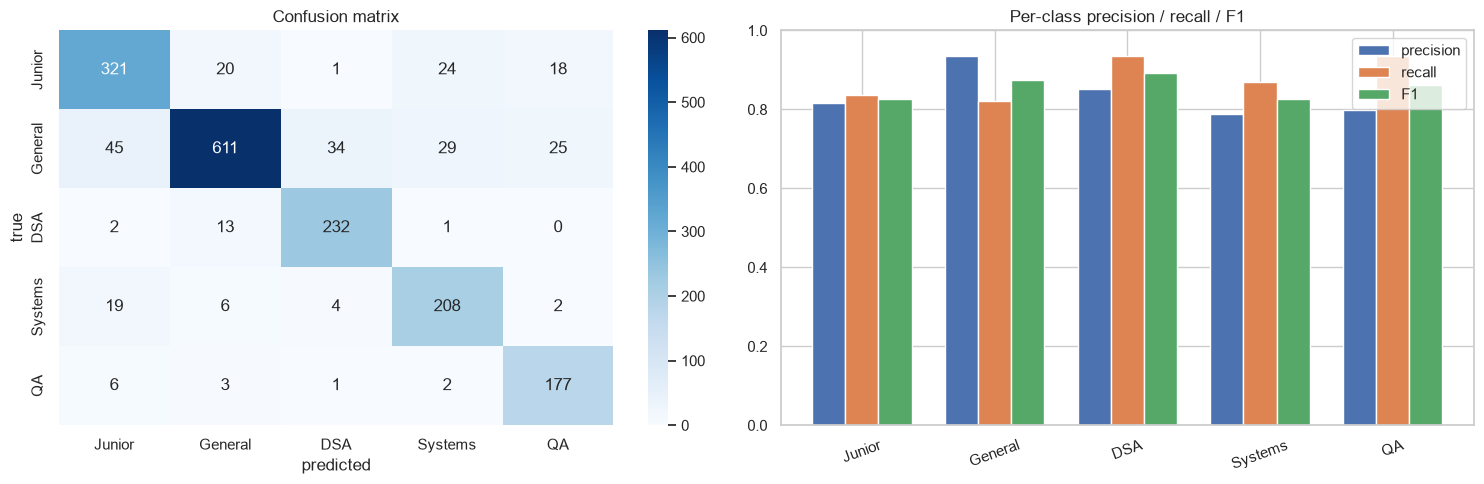

In [18]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[r.split(" ")[0] for r in cl.ROLES],
            yticklabels=[r.split(" ")[0] for r in cl.ROLES], ax=a1)
a1.set_xlabel("predicted"); a1.set_ylabel("true"); a1.set_title("Confusion matrix")
xpos = np.arange(K)
a2.bar(xpos - 0.25, prf["precision"], 0.25, label="precision")
a2.bar(xpos, prf["recall"], 0.25, label="recall")
a2.bar(xpos + 0.25, prf["f1"], 0.25, label="F1")
a2.set_xticks(xpos); a2.set_xticklabels([r.split(" ")[0] for r in cl.ROLES], rotation=20)
a2.legend(); a2.set_title("Per-class precision / recall / F1"); a2.set_ylim(0, 1)
plt.tight_layout(); plt.show()

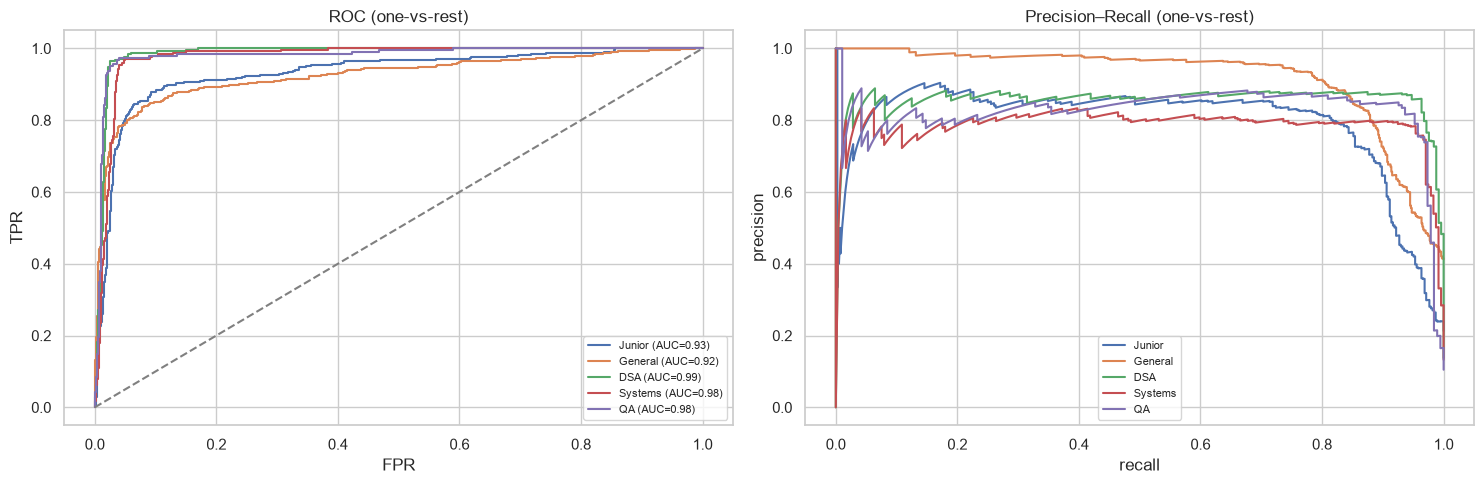

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve
Yte = label_binarize(y[te], classes=list(range(K)))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
for k in range(K):
    fpr, tpr, _ = roc_curve(Yte[:, k], probs_cal[:, k])
    a1.plot(fpr, tpr, label="%s (AUC=%.2f)" % (cl.ROLES[k].split(" ")[0], auc(fpr, tpr)))
    pr, rc, _ = precision_recall_curve(Yte[:, k], probs_cal[:, k])
    a2.plot(rc, pr, label=cl.ROLES[k].split(" ")[0])
a1.plot([0, 1], [0, 1], "--", color="gray"); a1.set_title("ROC (one-vs-rest)")
a1.set_xlabel("FPR"); a1.set_ylabel("TPR"); a1.legend(fontsize=8)
a2.set_title("Precision–Recall (one-vs-rest)"); a2.set_xlabel("recall"); a2.set_ylabel("precision"); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Interpretability — what drives each role?

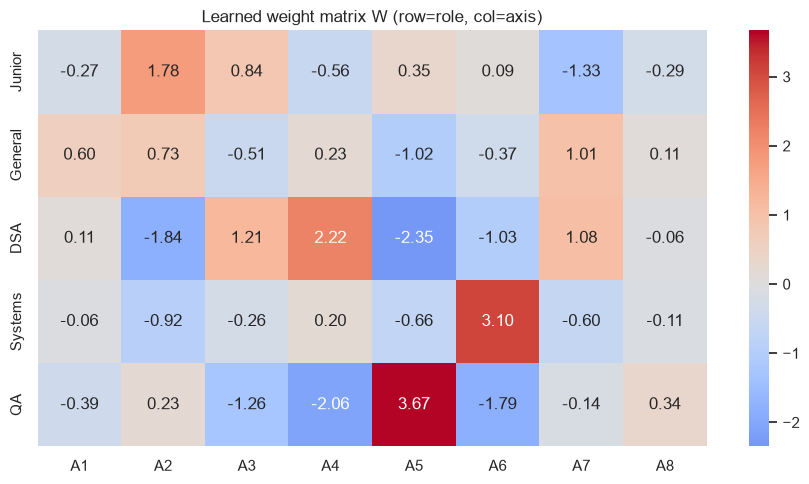

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(W, annot=True, fmt=".2f", center=0, cmap="coolwarm",
            xticklabels=cl.FEATURE_AXES, yticklabels=[r.split(" ")[0] for r in cl.ROLES], ax=ax)
ax.set_title("Learned weight matrix W (row=role, col=axis)"); plt.tight_layout(); plt.show()
# What this shows: positive weight = that axis pushes toward that role (e.g. A6→Systems).

## 9. Model selection — learning-rate / λ sweep

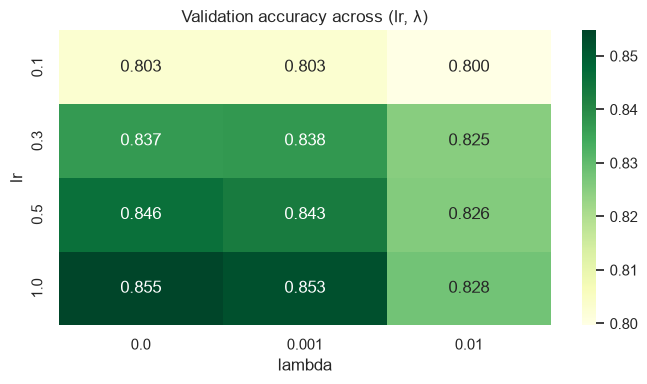

In [21]:
rows = []
for lr in [0.1, 0.3, 0.5, 1.0]:
    for lam in [0.0, 1e-3, 1e-2]:
        r = cl.train_softmax(Xz[tr], y[tr], K, lr=lr, lam=lam, epochs=400,
                             Xval=Xz[va], yval=y[va], class_weight=class_weight, seed=42)
        rows.append((lr, lam, r["history"]["val_acc"][-1]))
sweep = pd.DataFrame(rows, columns=["lr", "lambda", "val_acc"])
piv = sweep.pivot(index="lr", columns="lambda", values="val_acc")
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="YlGn", ax=ax)
ax.set_title("Validation accuracy across (lr, λ)"); plt.tight_layout(); plt.show()

## 10. Face validity vs Stack Overflow `DevType` (Cohen's κ)

In [22]:
if so_df is not None:
    from sklearn.metrics import cohen_kappa_score
    OOP = ["java", "c#", "c++", "kotlin", "python", "scala"]
    CONC = ["go", "rust", "c++", "java", "scala"]
    rows, truth = [], []
    ridx = cl.role_index(cl.ROLES)
    sample = so_df.dropna(subset=["DevType"]).sample(min(3000, len(so_df)), random_state=42)
    for _, r in sample.iterrows():
        langs = str(r.get("LanguageHaveWorkedWith", "")).lower()
        yrs = pd.to_numeric(r.get("YearsCodePro", 3), errors="coerce"); yrs = 3 if pd.isna(yrs) else yrs
        lvl = min(0.4 + 0.05 * float(yrs), 0.95)
        vec = [lvl, lvl if any(o in langs for o in OOP) else 0.4, lvl, lvl,
               lvl, 0.7 if any(c in langs for c in CONC) else 0.35, lvl, 0.5]
        rows.append(vec)
        low = str(r["DevType"]).lower()
        truth.append(next((ridx[role] for key, role in cl.DEVTYPE_TO_ROLE.items() if key in low), None))
    rows = np.array(rows); keep = [i for i, t in enumerate(truth) if t is not None]
    pred = cl.predict_proba(rows[keep], W, b, mu, sd, T).argmax(1)
    kappa = cohen_kappa_score([truth[i] for i in keep], pred)
    print("Face-validity Cohen's κ (model vs SO DevType heuristic): %.3f over %d devs" % (kappa, len(keep)))
    print("NOTE: SO measures multi-language pros, not Java sub-skills — κ is a sanity check, not ground truth.")
else:
    print("SO survey not loaded — skipping the κ cross-check.")

Face-validity Cohen's κ (model vs SO DevType heuristic): -0.019 over 2348 devs
NOTE: SO measures multi-language pros, not Java sub-skills — κ is a sanity check, not ground truth.


## 11. Export artifacts

In [23]:
OUT = "career_artifacts"; os.makedirs(OUT, exist_ok=True)
np.savez(os.path.join(OUT, "model_weights.npz"), W=W, b=b, T=np.array([T]))
json.dump({"mu": mu.tolist(), "sd": sd.tolist(), "axes": cl.FEATURE_AXES},
          open(os.path.join(OUT, "scaler.json"), "w"), indent=2)
json.dump(cl.DEFAULT_ROLE_MATRIX, open(os.path.join(OUT, "role_matrix.json"), "w"), indent=2)
json.dump({r: i for i, r in enumerate(cl.ROLES)}, open(os.path.join(OUT, "label_map.json"), "w"), indent=2)
json.dump({"axes": cl.FEATURE_AXES, "names": cl.AXIS_NAMES}, open(os.path.join(OUT, "feature_axes.json"), "w"), indent=2)
json.dump({"model_version": "numpy-softmax-colab",
           "test_top1_acc": round(float((y_pred == y[te]).mean()), 4),
           "test_top3_acc": round(cl.topk_accuracy(probs_cal, y[te], 3), 4),
           "macro_f1": round(prf["macro_f1"], 4),
           "ece_before": round(ece_b, 4), "ece_after": round(ece_a, 4),
           "temperature": round(T, 4), "confusion_matrix": cm.tolist()},
          open(os.path.join(OUT, "metrics.json"), "w"), indent=2)

with zipfile.ZipFile("career_artifacts.zip", "w") as z:
    for f in os.listdir(OUT):
        z.write(os.path.join(OUT, f), f)
print("Wrote career_artifacts.zip")
if IN_COLAB:
    from google.colab import files; files.download("career_artifacts.zip")

Wrote career_artifacts.zip


## 12. Conclusion & threats to validity

- **What this is:** a calibrated, interpretable role classifier over 8 SWEBOK-aligned axes,
  trained by weak supervision from an O*NET/ESCO-informed matrix.
- **Threats:** (1) *label provenance* — trained on synthetic profiles, so it learns the matrix's
  boundaries, not real hiring outcomes; (2) *domain shift* — SO survey ≠ Java learners (κ is a
  sanity check only); (3) *narrow signal* — a short Java quiz is thin evidence, hence the
  service's evidence gate and "aspirational/insufficient evidence" flag for non-SE roles.
- **Upgrade path:** log `(profile → shown prediction → feedback)` in production and retrain on
  real labels; this notebook then swaps synthetic `X,y` for the logged data unchanged.

Drop `career_artifacts.zip` into `app/services/career/artifacts/` to serve the model.